In [115]:
""" Imports and loading the data"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path.cwd().parent
csv_path = PROJECT_ROOT / "archive" / "neo_v2.csv"
df = pd.read_csv(csv_path)

print("Shape:", df.shape)
df.dtypes

print("Missing values per column:")
df.isnull().sum()   # Each cell 1 / 0 -> adds them together

Shape: (90836, 10)
Missing values per column:


id                    0
name                  0
est_diameter_min      0
est_diameter_max      0
relative_velocity     0
miss_distance         0
orbiting_body         0
sentry_object         0
absolute_magnitude    0
hazardous             0
dtype: int64

In [116]:
""" Change hazardous from (True/False) to (1/0)"""
df["hazardous_int"] = df["hazardous"].astype(int)
df = df.drop(columns=["hazardous"])  # (boolean) dropped, hazardous_int kept

print("Remaining columns:", list(df.columns))

Remaining columns: ['id', 'name', 'est_diameter_min', 'est_diameter_max', 'relative_velocity', 'miss_distance', 'orbiting_body', 'sentry_object', 'absolute_magnitude', 'hazardous_int']


In [117]:
""" Dropping non-informative columns """
print("Unique values in orbiting_body:", df["orbiting_body"].unique())  # Check for unique values
print("Unique values in sentry_object:", df["sentry_object"].unique())

drop_cols = ["id", "name"]
if df["orbiting_body"].nunique() == 1:  # Distinct value count, exclude Nan
    drop_cols.append("orbiting_body")
if df["sentry_object"].nunique() == 1:
    drop_cols.append("sentry_object")


df = df.drop(columns=drop_cols) # Removes columns from dataframe
print("Dropped columns:", drop_cols)
print("Remaining columns:", list(df.columns))

Unique values in orbiting_body: <StringArray>
['Earth']
Length: 1, dtype: str
Unique values in sentry_object: [False]
Dropped columns: ['id', 'name', 'orbiting_body', 'sentry_object']
Remaining columns: ['est_diameter_min', 'est_diameter_max', 'relative_velocity', 'miss_distance', 'absolute_magnitude', 'hazardous_int']


In [118]:
""" Correlation """
numeric_cols_with_min =  ["est_diameter_min", "est_diameter_max",
                        "relative_velocity", "miss_distance", "absolute_magnitude"]

print("Correlation between est_diameter_min and est_diameter_max:",
      df["est_diameter_min"].corr(df["est_diameter_max"]))

print()
print("Correlation of each feature with the target:")
df[numeric_cols_with_min + ["hazardous_int"]].corr()["hazardous_int"]    # Pearsons correlation coefficient

Correlation between est_diameter_min and est_diameter_max: 1.0

Correlation of each feature with the target:


est_diameter_min      0.183363
est_diameter_max      0.183363
relative_velocity     0.191185
miss_distance         0.042302
absolute_magnitude   -0.365267
hazardous_int         1.000000
Name: hazardous_int, dtype: float64

In [119]:
""" Drop est_diameter_min because of correlation with est_diameter_max"""
df = df.drop(columns=["est_diameter_min"])

numeric_cols = ["est_diameter_max", "relative_velocity", "miss_distance", "absolute_magnitude"]
print("Remaining columns:", list(df.columns))

Remaining columns: ['est_diameter_max', 'relative_velocity', 'miss_distance', 'absolute_magnitude', 'hazardous_int']


In [120]:
""" Summary of statistics"""
df[numeric_cols].describe()


,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude
count,90836.000000,90836.000000,9.083600e+04,90836.000000
mean,0.284947,48066.918918,3.706655e+07,23.527103
std,0.667491,25293.296961,2.235204e+07,2.894086
min,0.001362,203.346433,6.745533e+03,9.230000
25%,0.043057,28619.020645,1.721082e+07,21.340000
50%,0.108153,44190.117890,3.784658e+07,23.700000
75%,0.320656,62923.604633,5.654900e+07,25.700000
max,84.730541,236990.128088,7.479865e+07,33.200000


In [121]:
""" Checking "ratio" between hazardous and non-hazardous"""
print(df["hazardous_int"].value_counts())  # Count how many times hazardous int appears
print()
print(df["hazardous_int"].value_counts(normalize=True) * 100)

hazardous_int
0    81996
1     8840
Name: count, dtype: int64

hazardous_int
0    90.268176
1     9.731824
Name: proportion, dtype: float64


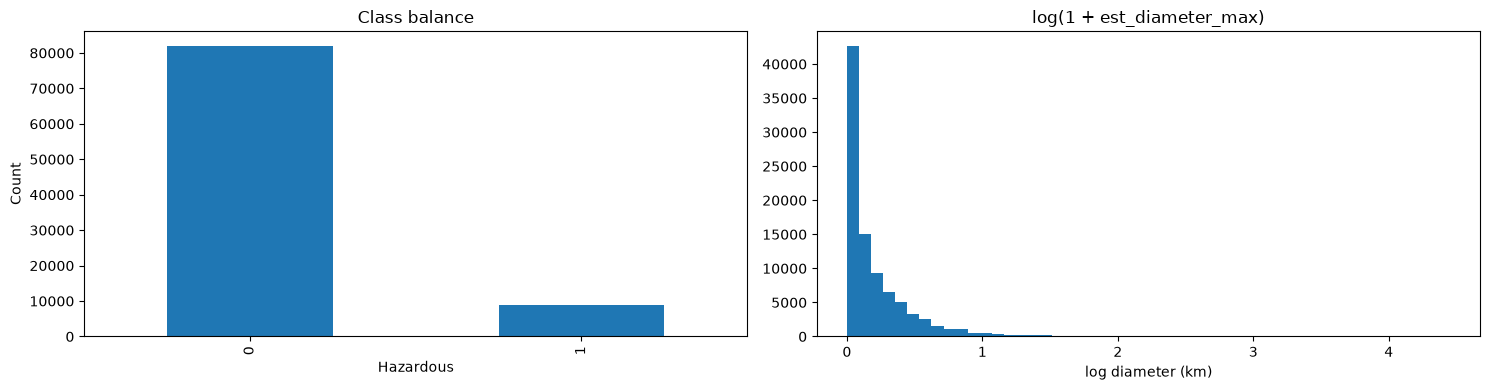

In [122]:
""" Visulaization """
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

df["hazardous_int"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Class balance")
axes[0].set_xlabel("Hazardous")
axes[0].set_ylabel("Count")

axes[1].hist(np.log1p(df["est_diameter_max"]), bins=50)
axes[1].set_title("log(1 + est_diameter_max)")
axes[1].set_xlabel("log diameter (km)")

plt.tight_layout()
plt.show()

In [123]:
""" Save output, figures and data """
df.to_csv("clean_data.csv", index = False)
fig.savefig("plot_overview.png", dpi = 150)

print("Shape of clean_data.csv:", df.shape)
print("Columns in clean_data.csv", list(df.columns))

Shape of clean_data.csv: (90836, 5)
Columns in clean_data.csv ['est_diameter_max', 'relative_velocity', 'miss_distance', 'absolute_magnitude', 'hazardous_int']


In [124]:
""" Splitting clean_data.csv to train/test data"""
clean_df = pd.read_csv("clean_data.csv")

print("Shape", clean_df.shape)
print("Columns:", list(clean_df.columns))

train_data, test_data = train_test_split(
    clean_df,
    test_size = 0.2,
    stratify=clean_df["hazardous_int"], # Splits hazardous_int evenly
    random_state=42   # Same split each time you run the cell
)

print("\n")
train_data.to_csv("train_data.csv", index=False)  #False for plain csv data
print("train_data.csv saved")
test_data.to_csv("test_data.csv", index=False)
print("test_data.csv saved")
print("\n")
print("Train data shape", train_data.shape)
print(train_data["hazardous_int"].value_counts())
print(train_data["hazardous_int"].value_counts(normalize=True) * 100)
print("\n")
print("Test data shape", test_data.shape)
print(test_data["hazardous_int"].value_counts())
print(test_data["hazardous_int"].value_counts(normalize=True) * 100)

Shape (90836, 5)
Columns: ['est_diameter_max', 'relative_velocity', 'miss_distance', 'absolute_magnitude', 'hazardous_int']


train_data.csv saved
test_data.csv saved


Train data shape (72668, 5)
hazardous_int
0    65596
1     7072
Name: count, dtype: int64
hazardous_int
0    90.268068
1     9.731932
Name: proportion, dtype: float64


Test data shape (18168, 5)
hazardous_int
0    16400
1     1768
Name: count, dtype: int64
hazardous_int
0    90.268604
1     9.731396
Name: proportion, dtype: float64


In [125]:
""" Libraries needed for Stage 2 """

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import GradientBoostingClassifier

In [126]:
""" Load train / test data and scaling it """

train_data = pd.read_csv("train_data.csv")
test_data = pd.read_csv("test_data.csv")

feature_cols = ["est_diameter_max", "relative_velocity", "miss_distance", "absolute_magnitude"]

X_train = train_data[feature_cols]
y_train = train_data["hazardous_int"]

X_test = test_data[feature_cols]
y_test = test_data["hazardous_int"]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
    # y data is boolean

In [127]:
""" Logistic Regression"""

model = LogisticRegression(class_weight='balanced')
model.fit(X_train_scaled, y_train)  # Finding weights and Biases

print("Logisitc Regression fitted")
print("Weights: ", model.coef_)
print("Bias: ", model.intercept_)

Logisitc Regression fitted
Weights:  [[-1.49393843  0.24106585 -0.35662993 -3.74141072]]
Bias:  [-2.18518563]


In [128]:
""" Prediction on test set """
y_pred = model.predict(X_test_scaled)

Logisitc Regression Confusion matrix:
[[12631  3769]
 [  120  1648]]


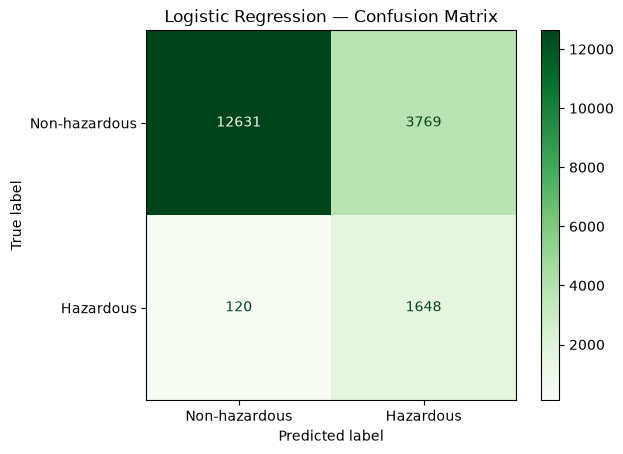

In [129]:
""" Confusion matrix of the Logisitc Regression """

cm = confusion_matrix(y_test, y_pred)
print("Logisitc Regression Confusion matrix:")
print(cm)

# Visualization of the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-hazardous", "Hazardous"])
disp.plot(cmap="Greens") 
plt.title("Logistic Regression — Confusion Matrix")
plt.show()

In [137]:
""" Confusion matrix analysis (Logisitic Regression) """

TN_LG = cm[0][0]
FP_LG = cm[0][1]
FN_LG = cm[1][0]
TP_LG = cm[1][1]

accuracy = (TP_LG + TN_LG) / (TP_LG + TN_LG + FP_LG + FN_LG)

if (TP_LG + FP_LG) > 0:
    precision = TP_LG / (TP_LG + FP_LG)
else:
    precision = 0

if (TP_LG + FN_LG) > 0:
    recall = TP_LG / (TP_LG + FN_LG)
else:
    recall = 0

if (precision + recall) > 0:
    f1 = 2 * (precision * recall) / (precision + recall)
else:
    f1 = 0

print(f"\nAccuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")


Accuracy:  0.7859
Precision: 0.3042
Recall:    0.9321
F1-score:  0.4587


In [131]:
""" Gradient Boosting """

GB_model = GradientBoostingClassifier(random_state=42)
GB_model.fit(X_train, y_train)

y_pred_GB = GB_model.predict(X_test)

Gradient Boosting Confusion matrix
[[16349    51]
 [ 1498   270]]


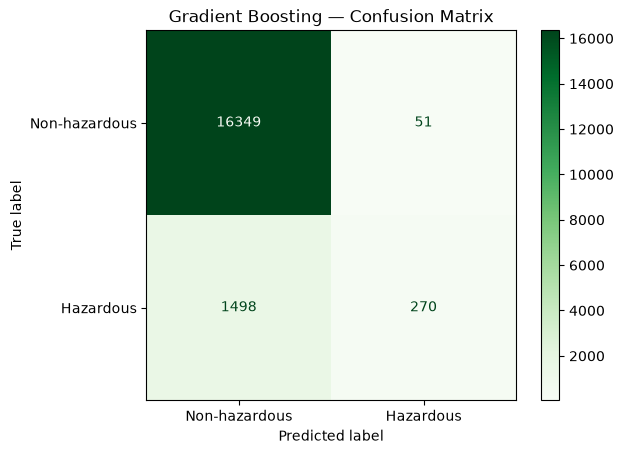

In [132]:
""" Confusion matrix of the Gradient Boosting """

cm_GB = confusion_matrix(y_test, y_pred_GB)
print("Gradient Boosting Confusion matrix")
print(cm_GB)

disp_GB = ConfusionMatrixDisplay(confusion_matrix=cm_GB, display_labels=["Non-hazardous", "Hazardous"])
disp_GB.plot(cmap="Greens")
plt.title("Gradient Boosting — Confusion Matrix")
plt.show()

In [136]:
""" Confusion matrix analysis (Gradient Boosting) """

TN_GB = cm_GB[0][0]
FP_GB = cm_GB[0][1]
FN_GB = cm_GB[1][0]
TP_GB = cm_GB[1][1]

accuracy_GB = (TP_GB + TN_GB) / (TP_GB + TN_GB + FP_GB + FN_GB)

if (TP_GB + FP_GB) > 0:
    precision_GB = TP_GB / (TP_GB + FP_GB)
else:
    precision_GB = 0

if (TP_GB + FN_GB) > 0:
    recall_GB = TP_GB / (TP_GB + FN_GB)
else:
    recall_GB = 0

if (precision_GB + recall_GB) > 0:
    f1_GB = 2 * (precision_GB * recall_GB) / (precision_GB + recall_GB)
else:
    f1_GB = 0

print(f"\nAccuracy:  {accuracy_GB:.4f}")
print(f"Precision: {precision_GB:.4f}")
print(f"Recall:    {recall_GB:.4f}")
print(f"F1-score:  {f1_GB:.4f}")


Accuracy:  0.9147
Precision: 0.8411
Recall:    0.1527
F1-score:  0.2585


In [134]:
""" Logisitc Regression vs Gradient Boosting (Confusion matrix) """

print("\nComparison:")
print(f"{'Metric':<12}{'Logistic Reg':<15}{'Gradient Boost'}")
print(f"{'Accuracy':<12}{accuracy:<15.4f}{accuracy_GB:.4f}")
print(f"{'Precision':<12}{precision:<15.4f}{precision_GB:.4f}")
print(f"{'Recall':<12}{recall:<15.4f}{recall_GB:.4f}")
print(f"{'F1-score':<12}{f1:<15.4f}{f1_GB:.4f}")


Comparison:
Metric      Logistic Reg   Gradient Boost
Accuracy    0.7859         0.9147
Precision   0.3042         0.8411
Recall      0.9321         0.1527
F1-score    0.4587         0.2585


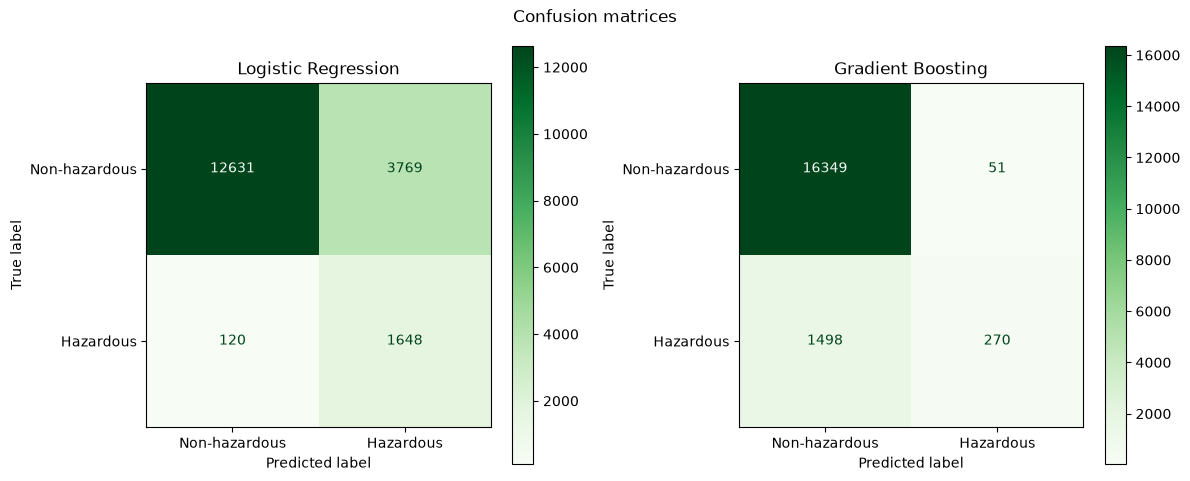

In [ ]:
""" Confusion matrices """

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

disp.plot(ax=axes[0], cmap="Greens")
axes[0].set_title("Logistic Regression")

disp_GB.plot(ax=axes[1], cmap="Greens")
axes[1].set_title("Gradient Boosting")

plt.suptitle("Confusion matrices")
plt.tight_layout()
plt.show()